In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKyiv
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = AerSimulator()

# backend=FakeKyiv()
# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [2]:


nb_qubits = 6

N = 2**nb_qubits
m = np.zeros((N,N))
for j in range(N):
    if j == N-1:
        break
    else:
       m[j,j+1] = -1 

for j in range(N):
    if j == N-1:
        break
    else:
       m[j+1,j] = -1 
for j in range(N):
   m[j,j] = 2 
m[0] = np.array([1]+ [0]*(N-1))
m[1,0] = 0

# b = np.array([0]+[1]*47+[2]*5+[0]*11])

c = 1e-0
v0 = 1
y = 1
b = np.array([0,c,0,0,0,0,0,0,0,0,0,0,0,0,0,c+v0*y]*4)
b=b/np.linalg.norm(b)

In [3]:
np.linalg.det(m)



64.0000000000006

In [4]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([-4.85722573e-17+2.08166817e-17j,  2.23606798e-01-2.22044605e-16j,
        1.38777878e-17+4.16333634e-17j, -1.23259516e-32-3.08148791e-33j,
       -1.38777878e-17+3.46944695e-17j,  5.39260384e-33-5.39260384e-33j,
       -1.84889275e-32+3.85185989e-33j,  1.71056941e-48-6.50016377e-48j,
       -5.55111512e-17+6.93889390e-17j,  1.15555797e-32-2.85037632e-32j,
        3.08148791e-32+1.54074396e-32j, -2.73691106e-48-5.47382213e-48j,
       -1.38777878e-17+2.77555756e-17j, -9.24446373e-33-6.16297582e-33j,
       -9.71445147e-17+2.77555756e-17j,  4.47213595e-01+1.11022302e-16j,
       -4.85722573e-17+2.08166817e-17j,  2.23606798e-01-2.22044605e-16j,
        1.38777878e-17+4.16333634e-17j, -1.23259516e-32-3.08148791e-33j,
       -1.38777878e-17+3.46944695e-17j,  5.39260384e-33-5.39260384e-33j,
       -1.84889275e-32+3.85185989e-33j,  1.71056941e-48-6.50016377e-48j,
       -5.55111512e-17+6.93889390e-17j,  1.15555797e-32-2.85037632e-32j,
        3.08148791e-32+1.54074396e-32j, -2.73691106

In [5]:
def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(p,q,i,j,k,l):
        return np.kron(p,np.kron(q,np.kron(i,np.kron(j,np.kron(k,l)))))
    M1 = (np.dot(np.dot(Ub,tensor(z,I,I,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,z,I,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,z,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,z,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,I,z,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,I,I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I,I,I,I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

In [6]:
d,u = np.linalg.eig(A)
d

array([1.19438555e+01-7.38613527e-17j, 1.02720576e+01-1.01338444e-16j,
       9.53474181e+00+3.72030325e-17j, 9.41120780e+00-2.64948304e-16j,
       9.41197035e+00-1.80457166e-16j, 7.84502294e+00+1.33030750e-16j,
       7.85230899e+00-1.09515188e-16j, 7.59827678e+00-1.08292917e-16j,
       7.36664009e+00+4.75848205e-17j, 7.32856677e+00+3.04297446e-16j,
       6.66866485e+00-6.71712204e-17j, 6.91869854e+00+3.39364575e-16j,
       5.71307232e+00+1.89922092e-16j, 5.59214491e+00+9.92908828e-17j,
       5.40275653e+00-1.13857358e-16j, 5.49187388e+00-7.49779599e-17j,
       5.15184720e+00-1.64042214e-16j, 4.99510578e+00+2.09111212e-16j,
       4.77978056e+00-1.61647946e-16j, 4.46809557e+00+5.77520109e-17j,
       3.98589495e+00+1.21835475e-16j, 3.64211313e+00-1.54516542e-17j,
       3.47181375e+00+5.04103487e-16j, 3.42929703e+00-1.81471538e-16j,
       3.28207514e+00-5.33866575e-17j, 2.99982107e+00-1.98443495e-16j,
       2.56948109e+00+3.76719087e-17j, 2.40233999e+00-3.15847538e-16j,
      

In [7]:
U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 
U5=scl.expm(2**4*2*np.pi*1j*A) 
U6=scl.expm(2**5*2*np.pi*1j*A) 
U7=scl.expm(2**6*2*np.pi*1j*A) 
U8=scl.expm(2**7*2*np.pi*1j*A)
U9=scl.expm(2**8*2*np.pi*1j*A) 
U10=scl.expm(2**9*2*np.pi*1j*A) 
U11=scl.expm(2**10*2*np.pi*1j*A) 
U12=scl.expm(2**11*2*np.pi*1j*A)
U13=scl.expm(2**12*2*np.pi*1j*A) 
U14=scl.expm(2**13*2*np.pi*1j*A) 
U15=scl.expm(2**14*2*np.pi*1j*A)
U16=scl.expm(2**15*2*np.pi*1j*A) 

 
u1gate=UnitaryGate(U1)
u2gate=UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)
u5gate=UnitaryGate(U5)
u6gate=UnitaryGate(U6)
u7gate=UnitaryGate(U7)
u8gate=UnitaryGate(U8)
u9gate=UnitaryGate(U9)
u10gate=UnitaryGate(U10)
u11gate=UnitaryGate(U11)
u12gate=UnitaryGate(U12)
u13gate=UnitaryGate(U13)
u14gate=UnitaryGate(U14)
u15gate=UnitaryGate(U15)
u16gate=UnitaryGate(U16)



In [8]:
Id = np.identity(2**nb_qubits)
z0 = np.array([[1,0],
               [0,0]])
z1 = np.array([[0,0],
               [0,1]])

CU1 = np.kron(Id,z0) + np.kron(U1,z1)
CU2 = np.kron(Id,z0) + np.kron(U2,z1)
CU3 = np.kron(Id,z0) + np.kron(U3,z1)
CU4 = np.kron(Id,z0) + np.kron(U4,z1)
CU5 = np.kron(Id,z0) + np.kron(U5,z1)
CU6 = np.kron(Id,z0) + np.kron(U6,z1)
CU7 = np.kron(Id,z0) + np.kron(U7,z1)
CU8 = np.kron(Id,z0) + np.kron(U8,z1)
CU9 = np.kron(Id,z0) + np.kron(U9,z1)
CU10 = np.kron(Id,z0) + np.kron(U10,z1)
CU11 = np.kron(Id,z0) + np.kron(U11,z1)
CU12 = np.kron(Id,z0) + np.kron(U12,z1)
CU13 = np.kron(Id,z0) + np.kron(U13,z1)
CU14 = np.kron(Id,z0) + np.kron(U14,z1)
CU15 = np.kron(Id,z0) + np.kron(U15,z1)
CU16 = np.kron(Id,z0) + np.kron(U16,z1)



C_u1gate=UnitaryGate(CU1)
C_u2gate=UnitaryGate(CU2)
C_u3gate=UnitaryGate(CU3)
C_u4gate=UnitaryGate(CU4)
C_u5gate=UnitaryGate(CU5)
C_u6gate=UnitaryGate(CU6)
C_u7gate=UnitaryGate(CU7)
C_u8gate=UnitaryGate(CU8)
C_u9gate=UnitaryGate(CU9)
C_u10gate=UnitaryGate(CU10)
C_u11gate=UnitaryGate(CU11)
C_u12gate=UnitaryGate(CU12)
C_u13gate=UnitaryGate(CU13)
C_u14gate=UnitaryGate(CU14)
C_u15gate=UnitaryGate(CU15)
C_u16gate=UnitaryGate(CU16)


[0.17286133 0.12244153 0.13049922 0.19296309 0.52540844 0.39856645
 0.85690314 0.19894652 0.52757741 0.75097524 0.62621902 0.10408361
 0.84975224 0.78617069 0.97538879 0.08512419 0.47087014 0.97021634
 0.42546707 0.74564921 0.34380603 0.80570861 0.75927679 0.25372411
 0.93635803 0.60633748 0.42715002 0.5753946  0.69165086 0.65769128
 0.8488759  0.61142265 0.67476757 0.03506587 0.35111507 0.61801076
 0.6487269  0.51303413 0.89244265 0.05177995 0.68898346 0.65066658
 0.03191173 0.48593032 0.58740411 0.35855259 0.98600749 0.89104713
 0.92011771 0.23875365 0.98561524 0.17592047 0.53497773 0.12010742]


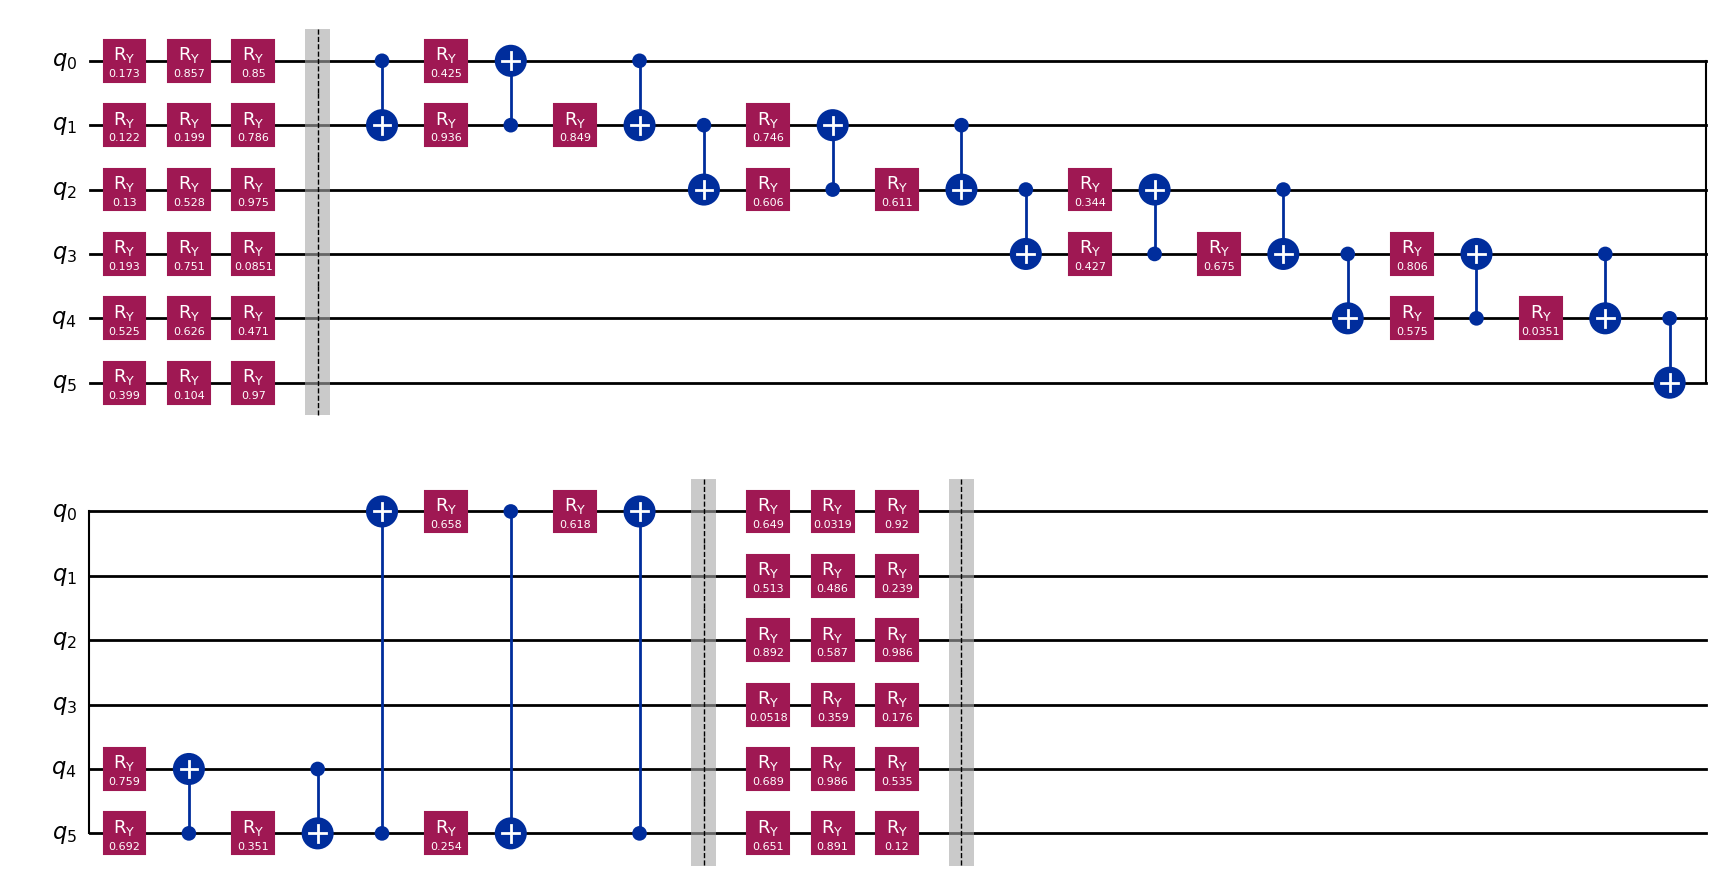

In [9]:
def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc


depth=1
qubits=list(range(nb_qubits))
N=len(qubits)
nb_params=int(9*N*depth)
# Parameters = np.array([random.random() for _ in range(0, nb_params)])

Parameters = np.array([0.17286133, 0.12244153, 0.13049922, 0.19296309, 0.52540844, 0.39856645,
 0.85690314, 0.19894652, 0.52757741, 0.75097524, 0.62621902, 0.10408361,
 0.84975224, 0.78617069, 0.97538879, 0.08512419, 0.47087014, 0.97021634,
 0.42546707, 0.74564921, 0.34380603, 0.80570861, 0.75927679, 0.25372411,
 0.93635803, 0.60633748, 0.42715002, 0.5753946 , 0.69165086, 0.65769128,
 0.8488759,  0.61142265, 0.67476757, 0.03506587, 0.35111507, 0.61801076,
 0.6487269,  0.51303413, 0.89244265, 0.05177995, 0.68898346, 0.65066658,
 0.03191173, 0.48593032, 0.58740411, 0.35855259, 0.98600749, 0.89104713,
 0.92011771, 0.23875365, 0.98561524, 0.17592047, 0.53497773, 0.12010742])
print(Parameters)
ansatz(Parameters).draw("mpl")

In [11]:
def circ(Parameters):
    x=QuantumRegister(22)
    c=ClassicalRegister(16)
    circuit = QuantumCircuit(x,c)
    circuit=circuit.compose(ansatz(Parameters),x[16:22])
    circuit.h(x[0:16])

#Apply the C-U operations where the controlled qubits are the qubits of the register x and the target from y    
    circuit.append(C_u1gate, [x[0],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u2gate, [x[1],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u3gate, [x[2],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u4gate, [x[3],x[16],x[17],x[18],x[19],x[20],x[21]])  
    circuit.append(C_u5gate, [x[4],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u6gate, [x[5],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u7gate, [x[6],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u8gate, [x[7],x[16],x[17],x[18],x[19],x[20],x[21]]) 
    circuit.append(C_u9gate, [x[8],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u10gate, [x[9],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u11gate, [x[10],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u12gate, [x[11],x[16],x[17],x[18],x[19],x[20],x[21]]) 
    circuit.append(C_u13gate, [x[12],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u14gate, [x[13],x[16],x[17],x[18],x[19],x[20],x[21]]) 
    circuit.append(C_u15gate, [x[14],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u16gate, [x[15],x[16],x[17],x[18],x[19],x[20],x[21]])    
#Apply the inverse QFT on the x register   
    circuit &= QFT(num_qubits = 16, approximation_degree = 0, do_swaps=True, 
                   inverse = True, insert_barriers = False, name ='qftinv')
    circuit.measure(x[0:16],c)       
    return circuit

In [12]:
1/2**16

1.52587890625e-05

/tmp/ipykernel_6207/623116687.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 16, approximation_degree = 0, do_swaps=True,


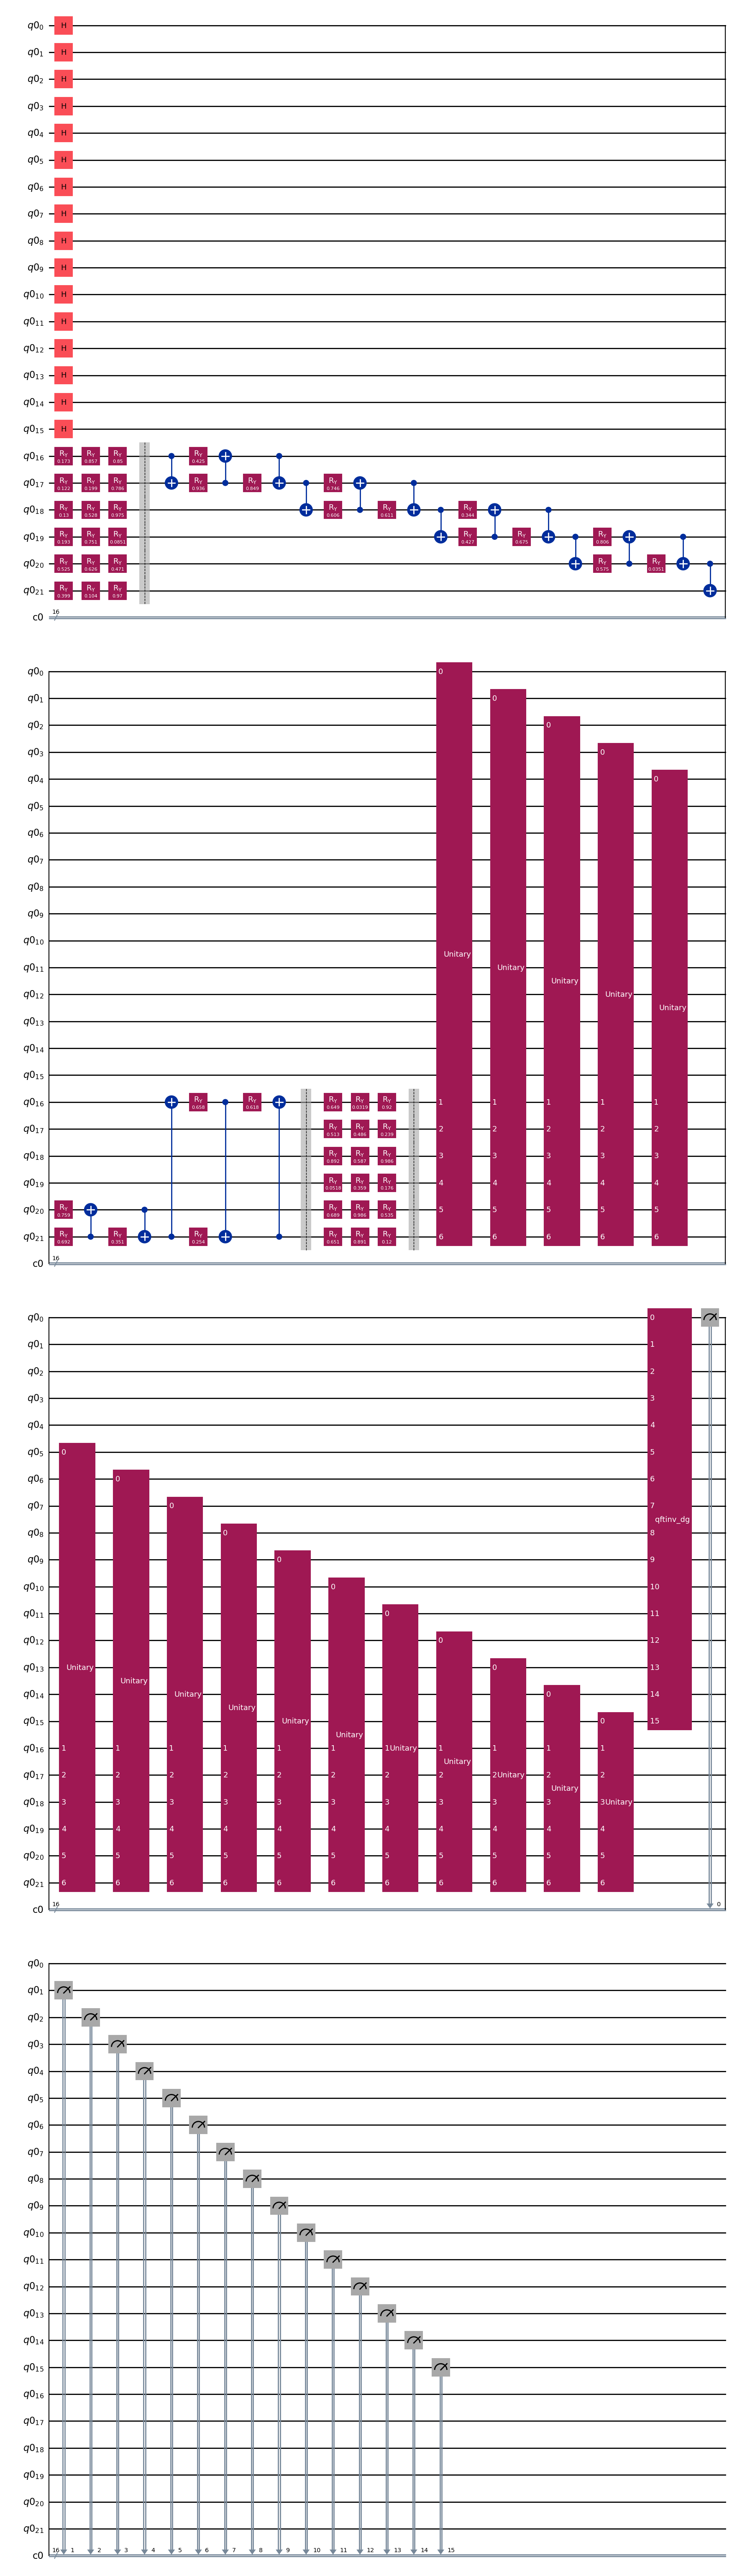

In [13]:
circ(Parameters).draw("mpl") 

In [14]:
shots = 100000
def cost(Parameters):
    job = backend.run(pm.run(circ(Parameters)),shots = shots).result()
    result = job.get_counts(0)
    if '0000000000000000'not in result: 
        res = 1
    else:
        res = 1 - result['0000000000000000']/shots
    return res
# cost(Parameters)


In [14]:
from qiskit_algorithms.optimizers import GradientDescent

learning_rate=0.1
def save(nfev,Parameters,cost,stepsize):
    global Cost,Params
    print(nfev,cost)
    Cost.append(cost)
    Params.append(Parameters)
Cost = []
Params = []

optimizer= GradientDescent(maxiter = 2000,learning_rate=learning_rate,tol=1e-4,callback=save)
optimizer.minimize(x0 = Parameters,fun = cost,jac=None)

/tmp/ipykernel_6207/623116687.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 16, approximation_degree = 0, do_swaps=True,


55 0.9947
110 0.99319
165 0.99363
220 0.99263
275 0.9924
330 0.99046
385 0.98993
440 0.98896
495 0.98801
550 0.9867900000000001
605 0.98545
660 0.98412
715 0.98334
770 0.98281
825 0.98188
880 0.98195
935 0.98186
990 0.97989
1045 0.97893
1100 0.97831
1155 0.97712
1210 0.97751
1265 0.97348
1320 0.97482
1375 0.97258
1430 0.97058
1485 0.9702
1540 0.96629
1595 0.96333
1650 0.9601500000000001
1705 0.9553
1760 0.95335
1815 0.95113
1870 0.94622
1925 0.94471
1980 0.93762
2035 0.93219
2090 0.9258500000000001
2145 0.92123
2200 0.9109700000000001
2255 0.90326
2310 0.89173
2365 0.87892
2420 0.85991
2475 0.8527
2530 0.8304
2585 0.82242
2640 0.76458
2695 0.7373799999999999
2750 0.70652
2805 0.72509
2860 0.7006600000000001
2915 0.63646
2970 0.62503
3025 0.53329
3080 0.44733999999999996
3135 0.45389999999999997
3190 0.40154999999999996
3245 0.37314
3300 0.31167999999999996
3355 0.28046000000000004
3410 0.31399
3465 0.25747
3520 0.26100999999999996
3575 0.17264000000000002
3630 0.16364
3685 0.1437300000


KeyboardInterrupt



KeyboardInterrupt: 

In [16]:
print(Cost)

[0.9947, 0.99319, 0.99363, 0.99263, 0.9924, 0.99046, 0.98993, 0.98896, 0.98801, 0.9867900000000001, 0.98545, 0.98412, 0.98334, 0.98281, 0.98188, 0.98195, 0.98186, 0.97989, 0.97893, 0.97831, 0.97712, 0.97751, 0.97348, 0.97482, 0.97258, 0.97058, 0.9702, 0.96629, 0.96333, 0.9601500000000001, 0.9553, 0.95335, 0.95113, 0.94622, 0.94471, 0.93762, 0.93219, 0.9258500000000001, 0.92123, 0.9109700000000001, 0.90326, 0.89173, 0.87892, 0.85991, 0.8527, 0.8304, 0.82242, 0.76458, 0.7373799999999999, 0.70652, 0.72509, 0.7006600000000001, 0.63646, 0.62503, 0.53329, 0.44733999999999996, 0.45389999999999997, 0.40154999999999996, 0.37314, 0.31167999999999996, 0.28046000000000004, 0.31399, 0.25747, 0.26100999999999996, 0.17264000000000002, 0.16364, 0.14373000000000002, 0.13700999999999997, 0.13731000000000004, 0.14117000000000002, 0.12941999999999998, 0.139, 0.13338000000000005, 0.11800999999999995, 0.11263999999999996, 0.11555000000000004, 0.11739999999999995, 0.10382999999999998, 0.10406000000000004, 0.

ERROR! Session/line number was not unique in database. History logging moved to new session 6318


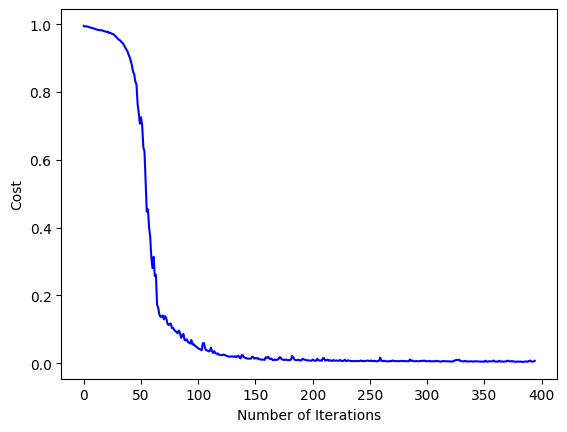

In [15]:
plt.plot(range(len(Cost)), Cost,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.show()


In [17]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)

In [18]:
e = []
F = []
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    psi = np.dot(m,state)
    Psi = psi/np.linalg.norm(psi)
    norm = np.dot(Psi,b)
    e.append(x_exact - state/norm)
    # f = abs(np.dot(Psi,b))**2
    f = abs(np.dot(state,x_exact))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))

In [20]:
print(F)

[0.005230593070106717, 0.006777322611061929, 0.006240535334742713, 0.007246287271156442, 0.007714008268285705, 0.009305704756117361, 0.010170758675475988, 0.010468468574857137, 0.011736409722960969, 0.0133335612448667, 0.014316034844264693, 0.016418240669090905, 0.016785129582449352, 0.0170563078590558, 0.017992679772049196, 0.018028279153036234, 0.018522276984251483, 0.020539843039239853, 0.0208603426690621, 0.0215436906546211, 0.022160688419989232, 0.023359818452102457, 0.025766561761487505, 0.024602775944818894, 0.02632038499195575, 0.029240296841978215, 0.029631735065454298, 0.033917028297512634, 0.03667847586620547, 0.03967555027448823, 0.04473746469218262, 0.047274837306604395, 0.049388879055046714, 0.0534930278445546, 0.05531313664540079, 0.062475824375519885, 0.06785143212899104, 0.07329158707101939, 0.07805935493376558, 0.08874169058393645, 0.09683045339122133, 0.10825795421439303, 0.11915624229526851, 0.13866826034710553, 0.14783511556732776, 0.16833618832759178, 0.1789300747

Text(0.5, 0, 'Iteration')

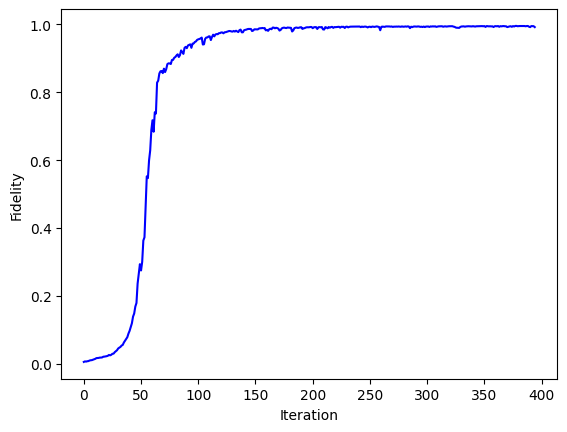

In [21]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(F)),F,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Fidelity')
plt.xlabel('Iteration')


In [22]:
norm_e[np.argmax(F)]

35.5127854057835

In [23]:
ef = abs(np.array(e[np.argmax(F)]))
ef

array([0.06201134, 0.47108872, 0.4669224 , 0.83705015, 1.13062269,
       1.7043099 , 1.61601707, 2.06137727, 3.0275315 , 2.79127733,
       3.40401575, 3.13873778, 3.95696934, 3.87007624, 4.23631573,
       4.17786561, 4.7183754 , 5.48446098, 4.8952155 , 5.72770404,
       5.26566641, 6.0482806 , 5.32765495, 6.21776136, 5.78853688,
       5.46203142, 5.78200857, 5.56345939, 5.94941541, 5.55457264,
       5.82066223, 5.58207307, 5.82115951, 5.74368639, 6.17126661,
       5.79909311, 5.92041126, 5.72469576, 6.14112877, 5.62788789,
       5.7209362 , 5.89626788, 5.73604507, 5.69530414, 5.17017815,
       5.43863302, 5.0410058 , 5.09224381, 4.34114632, 4.31776026,
       4.06175414, 3.73850745, 3.35349805, 3.24790507, 2.95363939,
       2.57681134, 2.72989093, 2.08282304, 2.26459711, 1.48498716,
       1.53145532, 1.03328184, 0.97560157, 0.40319296])

In [25]:
X_opt  = np.array(Statevector(ansatz(Params[-1])))
psi = m@X_opt
psi = psi/np.linalg.norm(psi)

In [26]:
abs(np.array(e[-1]))

array([0.0704579 , 0.02444109, 0.00865715, 0.0313715 , 0.05428481,
       0.12431641, 0.13592426, 0.18853362, 0.30470795, 0.25652962,
       0.37202875, 0.32387452, 0.42910958, 0.4128891 , 0.48361644,
       0.48172457, 0.42657792, 0.56412983, 0.47535932, 0.63461771,
       0.5373566 , 0.69170608, 0.56962823, 0.75409215, 0.61372122,
       0.59675288, 0.63417669, 0.63999924, 0.68567211, 0.65392366,
       0.68204051, 0.68439624, 0.5632242 , 0.53735742, 0.65340952,
       0.57959201, 0.6190215 , 0.59636933, 0.68882347, 0.60938631,
       0.59865504, 0.6392626 , 0.62253186, 0.6309496 , 0.55844069,
       0.63808687, 0.54961789, 0.5957992 , 0.46006009, 0.50062082,
       0.43899234, 0.42508324, 0.38071639, 0.4263109 , 0.3290736 ,
       0.32113167, 0.31987743, 0.27448622, 0.2511059 , 0.18086844,
       0.19197589, 0.17814308, 0.09309978, 0.06690484])

In [27]:
X_opt

array([-0.01444396+0.j, -0.00290625+0.j,  0.00560484+0.j,  0.01198723+0.j,
        0.0184104 +0.j,  0.03449288+0.j,  0.03859842+0.j,  0.05110933+0.j,
        0.07665112+0.j,  0.06850042+0.j,  0.09390381+0.j,  0.08575804+0.j,
        0.10905728+0.j,  0.10745798+0.j,  0.12368309+0.j,  0.12502117+0.j,
        0.11468538+0.j,  0.14385305+0.j,  0.12624605+0.j,  0.15948529+0.j,
        0.14013771+0.j,  0.17237061+0.j,  0.14793556+0.j,  0.18634197+0.j,
        0.15815682+0.j,  0.15526935+0.j,  0.16353235+0.j,  0.16531705+0.j,
        0.17527111+0.j,  0.1693537 +0.j,  0.17570876+0.j,  0.17678276+0.j,
        0.15177684+0.j,  0.14630862+0.j,  0.16955566+0.j,  0.1538792 +0.j,
        0.16141851+0.j,  0.156231  +0.j,  0.17464044+0.j,  0.15781194+0.j,
        0.15506823+0.j,  0.16284905+0.j,  0.15887545+0.j,  0.16005731+0.j,
        0.14464911+0.j,  0.1604329 +0.j,  0.14175286+0.j,  0.15067631+0.j,
        0.12154927+0.j,  0.12856392+0.j,  0.11425138+0.j,  0.10972137+0.j,
        0.09894747+0.j,  

In [28]:
print(F)

[0.005230593070106717, 0.006777322611061929, 0.006240535334742713, 0.007246287271156442, 0.007714008268285705, 0.009305704756117361, 0.010170758675475988, 0.010468468574857137, 0.011736409722960969, 0.0133335612448667, 0.014316034844264693, 0.016418240669090905, 0.016785129582449352, 0.0170563078590558, 0.017992679772049196, 0.018028279153036234, 0.018522276984251483, 0.020539843039239853, 0.0208603426690621, 0.0215436906546211, 0.022160688419989232, 0.023359818452102457, 0.025766561761487505, 0.024602775944818894, 0.02632038499195575, 0.029240296841978215, 0.029631735065454298, 0.033917028297512634, 0.03667847586620547, 0.03967555027448823, 0.04473746469218262, 0.047274837306604395, 0.049388879055046714, 0.0534930278445546, 0.05531313664540079, 0.062475824375519885, 0.06785143212899104, 0.07329158707101939, 0.07805935493376558, 0.08874169058393645, 0.09683045339122133, 0.10825795421439303, 0.11915624229526851, 0.13866826034710553, 0.14783511556732776, 0.16833618832759178, 0.1789300747

In [29]:
print(norm_e)

[5.027703138640478, 5.035929612111618, 5.0396465900288305, 5.116750931691745, 5.140775054917938, 5.287054558505032, 5.388542276770868, 5.392399696323352, 5.486177424509988, 5.549846051375505, 5.607823880978354, 5.747259656583881, 5.914004403900164, 5.869298695629742, 5.823975978928482, 5.770813538054435, 5.983207394275209, 6.396254483775512, 6.593596022327092, 6.4747972421661, 6.6906459077884675, 6.704458591258679, 7.086317754071816, 6.7483463283520555, 6.7515290145816005, 6.830589574436338, 6.778253021531782, 7.161308227025462, 7.400178846931713, 7.931571609659586, 8.633810124241776, 8.755252989466731, 10.971416494955625, 10.985287492198179, 11.667397295553341, 10.397389218665888, 11.206382999291113, 14.052226585909704, 16.088951660796123, 17.57984082417722, 24.69127759711136, 27.79023821981525, 91.06898306034064, 469.9858866503619, 225.75879487215218, 327.2216698152764, 60.47761803475893, 29.761941947422002, 28.71837557896266, 16.505199582561726, 4.818507655690966, 4.487561852471009,

In [30]:
min(norm_e)

2.4655965131701825

In [31]:
1-max(F)

0.004466205597807527